# **Modelo Predictivo de Precipitaciones en el Valle de Aburrá**

## Proyecto de Grado

Pablo Gómez Mutis

### Cargar el dataset

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Proyecto de grado/Estacion_pluviometrica_24_2014-03-03_2025-01-31.csv")

df.head()

,codigo,fecha_hora,p1,p2,calidad
0,24,2014-03-03 13:38:21,0.0,0.0,1
1,24,2014-03-03 13:39:21,0.0,0.0,1
2,24,2014-03-03 13:40:21,0.0,0.0,1
3,24,2014-03-03 13:41:21,0.0,0.0,1
4,24,2014-03-03 13:42:21,0.0,0.0,1


In [ ]:
df = df.drop(columns=['codigo']).reset_index(drop=True)

In [ ]:
primera_fecha = df['fecha_hora'].min()
ultima_fecha = df['fecha_hora'].max()

print("Primera fecha:", primera_fecha)
print("Última fecha:", ultima_fecha)

Primera fecha: 2014-03-03 13:38:21
Última fecha: 2025-01-31 23:59:00


### Describe

In [ ]:
df.describe()

,p1,p2,calidad
count,5.459391e+06,5.459391e+06,5.459391e+06
mean,-3.150816e-01,-3.546927e-01,4.606420e+01
std,1.782696e+01,1.894704e+01,2.542387e+02
min,-9.990000e+02,-9.990000e+02,1.000000e+00
25%,0.000000e+00,0.000000e+00,1.000000e+00
50%,0.000000e+00,0.000000e+00,1.000000e+00
75%,0.000000e+00,0.000000e+00,1.000000e+00
max,7.650800e+01,2.542017e+03,2.512000e+03


### Verificar presencia de valores nulos

In [ ]:
df.isnull().any().any()


np.False_

### Distribución de momentos sin lluvia y con lluvia

Porcentaje sin lluvia: 99.0007676680421
Porcentaje con lluvia: 0.9992323319579052


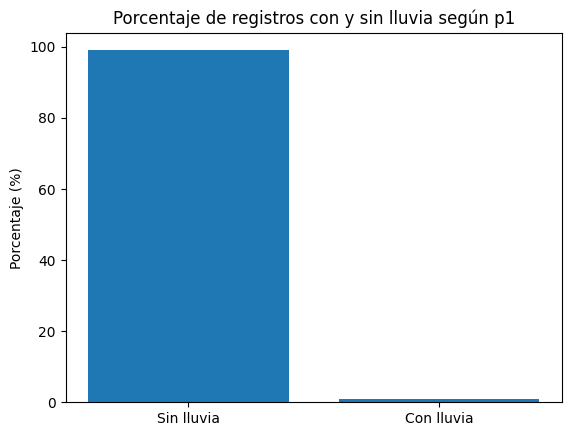

In [ ]:
import matplotlib.pyplot as plt

sin_lluvia = (df['p1'] == 0).sum()
con_lluvia = (df['p1'] != 0).sum()

total = len(df)

porc_sin_lluvia = sin_lluvia / total * 100
porc_con_lluvia = con_lluvia / total * 100

print("Porcentaje sin lluvia:", porc_sin_lluvia)
print("Porcentaje con lluvia:", porc_con_lluvia)

plt.bar(['Sin lluvia', 'Con lluvia'], [porc_sin_lluvia, porc_con_lluvia])
plt.ylabel('Porcentaje (%)')
plt.title('Porcentaje de registros con y sin lluvia según p1')
plt.show()


### Distribución de momentos con precipitación por intensidad

categoria
Llovizna           99.710293
Lluvia leve         0.268878
Lluvia intensa      0.011361
Lluvia moderada     0.007574
Tormenta            0.001894
Name: proportion, dtype: float64


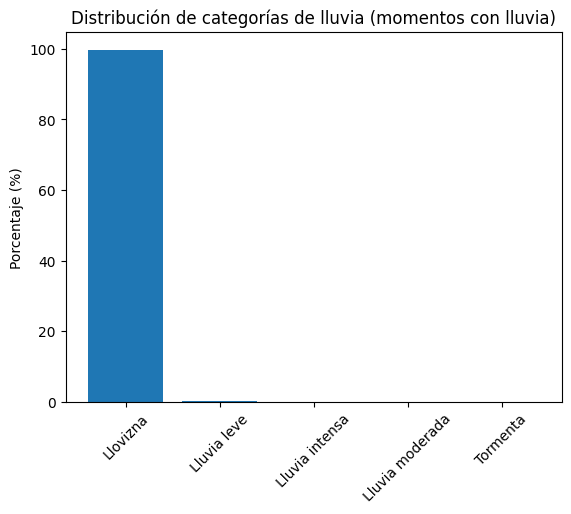

categoria
Llovizna           99.710293
Lluvia leve         0.268878
Lluvia intensa      0.011361
Lluvia moderada     0.007574
Tormenta            0.001894
Name: proportion, dtype: float64


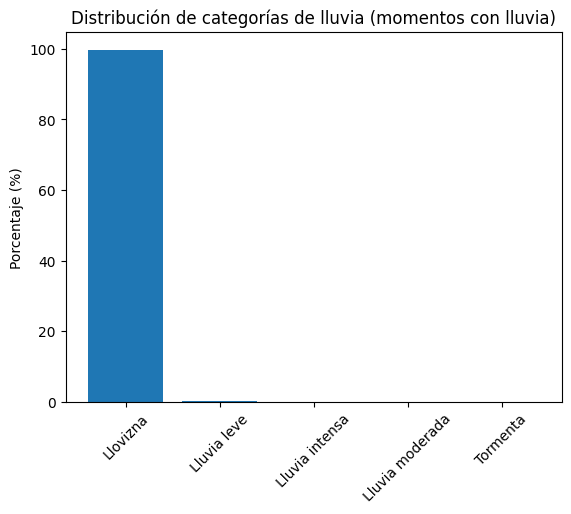

In [ ]:
df_lluvia = df[df['p1'] > 0].copy()

df_lluvia = df[df['p1'] > 0].copy()

def clasificar_lluvia(x):
    if 0 < x < 2:
        return "Llovizna"              # incluye traza (<0.254)
    elif 2 <= x < 6:
        return "Lluvia leve"
    elif 6 <= x < 8:
        return "Lluvia moderada"
    elif 8 <= x < 10:
        return "Lluvia intensa"
    else:
        return "Tormenta"

df_lluvia["categoria"] = df_lluvia["p1"].apply(clasificar_lluvia)

dist = df_lluvia["categoria"].value_counts(normalize=True) * 100
print(dist)

plt.bar(dist.index, dist.values)
plt.ylabel("Porcentaje (%)")
plt.title("Distribución de categorías de lluvia (momentos con lluvia)")
plt.xticks(rotation=45)
plt.show()



df_lluvia["categoria"] = df_lluvia["p1"].apply(clasificar_lluvia)

dist = df_lluvia["categoria"].value_counts(normalize=True) * 100
print(dist)

plt.bar(dist.index, dist.values)
plt.ylabel("Porcentaje (%)")
plt.title("Distribución de categorías de lluvia (momentos con lluvia)")
plt.xticks(rotation=45)
plt.show()


### Distribución de momentos con precipitación por intensidad (sin llovizna)

categoria
Lluvia leve        92.810458
Lluvia intensa      3.921569
Lluvia moderada     2.614379
Tormenta            0.653595
Name: proportion, dtype: float64


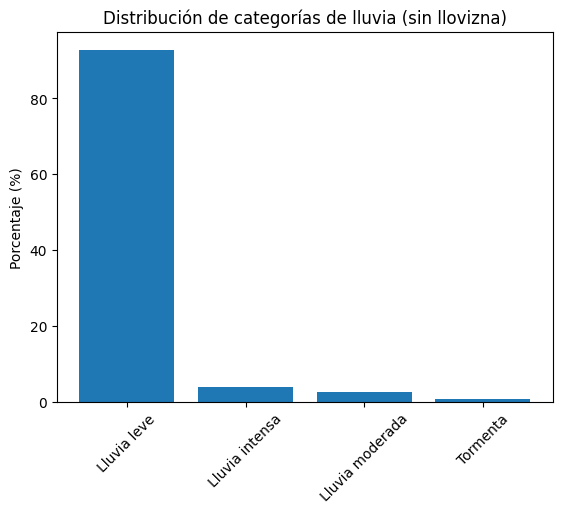

In [ ]:
df_lluvia = df[df['p1'] >= 2].copy()

def clasificar_lluvia(x):
    if 2 <= x < 6:
        return "Lluvia leve"
    elif 6 <= x < 8:
        return "Lluvia moderada"
    elif 8 <= x < 10:
        return "Lluvia intensa"
    else:
        return "Tormenta"

df_lluvia["categoria"] = df_lluvia["p1"].apply(clasificar_lluvia)

dist = df_lluvia["categoria"].value_counts(normalize=True) * 100
print(dist)

plt.bar(dist.index, dist.values)
plt.ylabel("Porcentaje (%)")
plt.title("Distribución de categorías de lluvia (sin llovizna)")
plt.xticks(rotation=45)
plt.show()


### Distribución de datos confiables (calidad = 1) y datos no confiables / no obtenidos (calidad != 1)

Filas con calidad = 1: 5240785
Filas con calidad distinta de 1: 218606


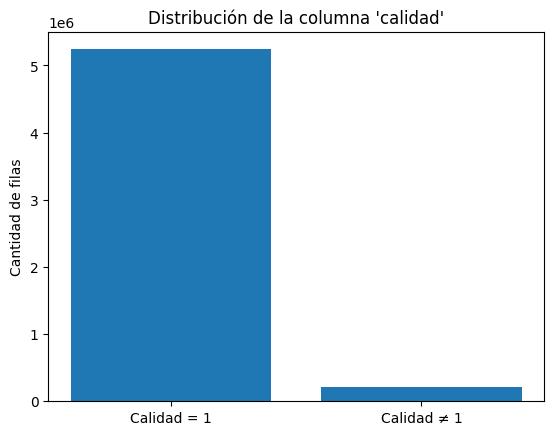

In [ ]:
calidad_1 = (df['calidad'] == 1).sum()

calidad_otros = (df['calidad'] != 1).sum()

print("Filas con calidad = 1:", calidad_1)
print("Filas con calidad distinta de 1:", calidad_otros)

labels = ["Calidad = 1", "Calidad ≠ 1"]
values = [calidad_1, calidad_otros]

plt.bar(labels, values)
plt.ylabel("Cantidad de filas")
plt.title("Distribución de la columna 'calidad'")
plt.show()


### Precipitación acumulada promedio por mes

Años con los 12 meses completos: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Promedio mensual (mm):
mes
1      68.6257
2      56.5051
3     156.8599
4     152.4085
5     208.5151
6     159.4625
7     102.7605
8     115.4539
9     179.8591
10    173.3922
11    178.7321
12     71.8283
Name: p1, dtype: float64


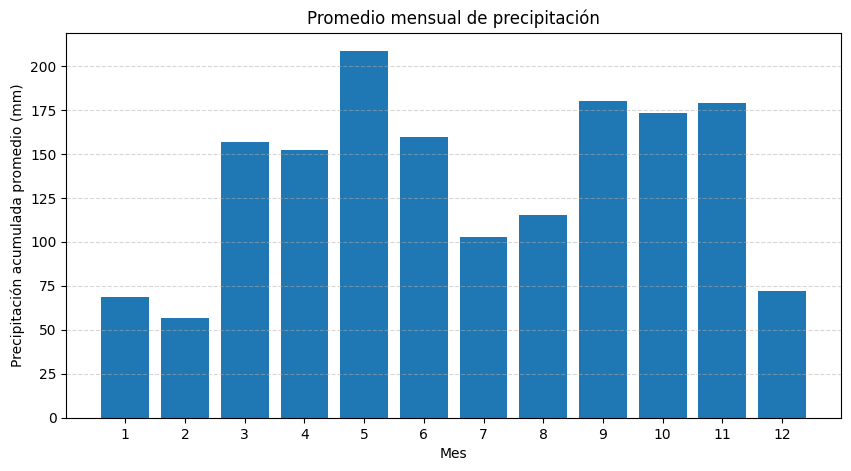

In [ ]:
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

df['p1'] = df['p1'].clip(lower=0)

df['año'] = df['fecha_hora'].dt.year
df['mes'] = df['fecha_hora'].dt.month

precip_mensual = df.groupby(['año', 'mes'])['p1'].sum().reset_index()

conteo_meses = precip_mensual.groupby('año')['mes'].nunique()
años_completos = conteo_meses[conteo_meses == 12].index.tolist()

print("Años con los 12 meses completos:", años_completos)

precip_filtrado = precip_mensual[precip_mensual['año'].isin(años_completos)]

promedio_mensual = precip_filtrado.groupby('mes')['p1'].mean()

print("Promedio mensual (mm):")
print(promedio_mensual)

plt.figure(figsize=(10,5))
plt.bar(promedio_mensual.index, promedio_mensual.values)
plt.xlabel("Mes")
plt.ylabel("Precipitación acumulada promedio (mm)")
plt.title("Promedio mensual de precipitación")
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


### Precipitación acumulada promedio por mes

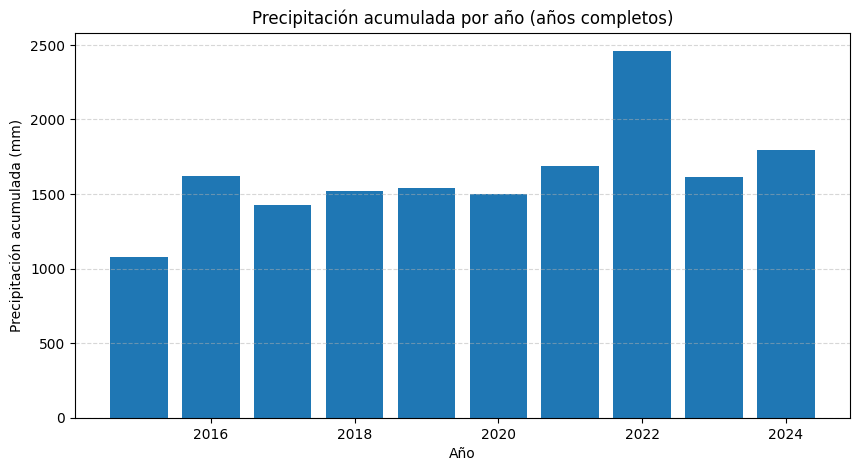

In [ ]:
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])
df['p1'] = df['p1'].clip(lower=0)
df['año'] = df['fecha_hora'].dt.year
df['mes'] = df['fecha_hora'].dt.month

precip_mensual = df.groupby(['año','mes'])['p1'].sum().reset_index()
precip_mensual = precip_mensual[~precip_mensual['año'].isin([2014, 2025])]

conteo_meses = precip_mensual.groupby('año')['mes'].nunique()
años_completos = conteo_meses[conteo_meses == 12].index.tolist()

precip_anual = precip_mensual[precip_mensual['año'].isin(años_completos)]
precip_anual = precip_anual.groupby('año')['p1'].sum()

plt.figure(figsize=(10,5))
plt.bar(precip_anual.index, precip_anual.values)
plt.xlabel("Año")
plt.ylabel("Precipitación acumulada (mm)")
plt.title("Precipitación acumulada por año (años completos)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
